In [32]:
# import 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

In [13]:
df = pd.read_csv('tweets.csv', encoding='latin-1')

# preview 
df.head()

,Unnamed: 0,text,favorited,favoriteCount,replyToSN,created,truncated,replyToSID,id,replyToUID,statusSource,screenName,retweetCount,isRetweet,retweeted,longitude,latitude
0,1,RT @mrvelstan: literally nobody:\r\nme:\r\n\r\...,False,0,NaN,2019-04-23 10:43:30,False,NaN,1120639328034676737,NaN,"<a href=""http://twitter.com/download/android"" ...",DavidAc96,637,True,False,NaN,NaN
1,2,"RT @agntecarter: im emotional, sorry!!\r\n\r\...",False,0,NaN,2019-04-23 10:43:30,False,NaN,1120639325199196160,NaN,"<a href=""http://twitter.com/download/iphone"" r...",NRmalaa,302,True,False,NaN,NaN
2,3,saving these bingo cards for tomorrow \r\n©\r\...,False,0,NaN,2019-04-23 10:43:30,False,NaN,1120639324683292674,NaN,"<a href=""http://twitter.com/download/iphone"" r...",jijitsuu,0,False,False,NaN,NaN
3,4,RT @HelloBoon: Man these #AvengersEndgame ads ...,False,0,NaN,2019-04-23 10:43:29,False,NaN,1120639323328540672,NaN,"<a href=""http://twitter.com/download/iphone"" r...",SahapunB,23781,True,False,NaN,NaN
4,5,"RT @Marvel: We salute you, @ChrisEvans! #Capta...",False,0,NaN,2019-04-23 10:43:29,False,NaN,1120639321571074048,NaN,"<a href=""http://twitter.com/download/iphone"" r...",stella22_97,13067,True,False,NaN,NaN


In [14]:
# total num of rows and columns 
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# check datatypes and missing values 
print("Dataset Information:")
df.info()

Dataset Shape: 15000 rows and 17 columns.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     15000 non-null  int64  
 1   text           15000 non-null  object 
 2   favorited      15000 non-null  bool   
 3   favoriteCount  15000 non-null  int64  
 4   replyToSN      397 non-null    object 
 5   created        15000 non-null  object 
 6   truncated      15000 non-null  bool   
 7   replyToSID     369 non-null    float64
 8   id             15000 non-null  int64  
 9   replyToUID     397 non-null    float64
 10  statusSource   15000 non-null  object 
 11  screenName     15000 non-null  object 
 12  retweetCount   15000 non-null  int64  
 13  isRetweet      15000 non-null  bool   
 14  retweeted      15000 non-null  bool   
 15  longitude      4 non-null      float64
 16  latitude       4 non-null     

In [20]:
# check for missing values 
df.isnull().sum()

# drop rows with missing values 
df = df.dropna(subset=['text'])

# check for total num of rows and columns after dropping missing values 
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")


Dataset Shape: 15000 rows and 16 columns.



In [23]:
print(df.columns)
#df = df.drop(columns=['Unnamed: 0'])

Index(['text', 'favorited', 'favoriteCount', 'replyToSN', 'created',
       'truncated', 'replyToSID', 'id', 'replyToUID', 'statusSource',
       'screenName', 'retweetCount', 'isRetweet', 'retweeted', 'longitude',
       'latitude'],
      dtype='object')


In [29]:
# basic descriptive stats 
# highlights followers, friends, and favs (likes)
average_favorited = df['favoriteCount'].mean()
average_retweet = df['retweetCount'].mean()

print(f"The average Twitter user in this dataset has {average_favorited:.2f} favourites.")
print(f"The average number of retweets (likes) associated with these users is {average_retweet:.2f}.")
 
# top 5 most favourited tweets
top_tweets_by_favourited = df[['screenName', 'text', 'favoriteCount']].sort_values(by='favoriteCount', ascending=False).head(5)
top_tweets_by_favourited

The average Twitter user in this dataset has 0.19 favourites.
The average number of retweets (likes) associated with these users is 5912.46.


,screenName,text,favoriteCount
4157,SSMusicTweet,"After #Viswasam, #Petta &amp; #Kanchana3 #Aven...",184
13147,oppomobileindia,"Heroic hand-held power and endurance, our Marv...",183
12371,TicketNew,#CONTEST: Here's a question about someone we a...,161
9876,hmvtweets,WIN an #AvengersEndgame merch bundle! Simply R...,159
7388,CevansOfficial,I just I love this picture! <U+0001F499> #Endg...,135


In [30]:
# top 5 most retweeted tweets 
top_tweets_by_retweet = df[['screenName', 'text', 'retweetCount']].sort_values(by='retweetCount', ascending=False).head(5)
top_tweets_by_retweet

,screenName,text,retweetCount
3487,billsup_,RT @Avengers: Whatever it takes. Watch the bra...,114850
7308,HelenaB94527435,RT @Marvel: Whatever it takes. Watch the brand...,100500
11373,dairlena,RT @Avengers: Here's your first look at the ne...,85686
4048,JuuanKrlos,RT @ChrisEvans: 1 month. #AvengersEndgame http...,66596
13623,VaitheesGVW,"RT @MarvelStudios: Before were done, we stil...",48795


In [34]:
# filter 
all_tweets = " ".join(tweet for tweet in df['text'].astype(str))
all_tweets = all_tweets.lower()

words = re.findall(r'\b[a-z]{4,}\b', all_tweets)

stop_words = ['paytm','marvelstudios','what','endgame', 'movie', 'times','are', 'avengersendgame', 'https', 'these', 'with', 'helloboon', 'everywhere', 'this', 'your', 'that', 'world', 'marvel', 'avengers', 'here']
meaningful_words = [word for word in words if word not in stop_words]

word_counts = Counter(meaningful_words)
top_words = word_counts.most_common(15)

words_to_plot = [item[0] for item in top_words]
counts_to_plot = [item[1] for item in top_words]

print("Word frequencies calculated successfully!")

Word frequencies calculated successfully!


/var/folders/k7/t32643cn28qc5hpk99j57v_c0000gn/T/ipykernel_99335/3976523685.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words_to_plot, y=counts_to_plot, palette="viridis")


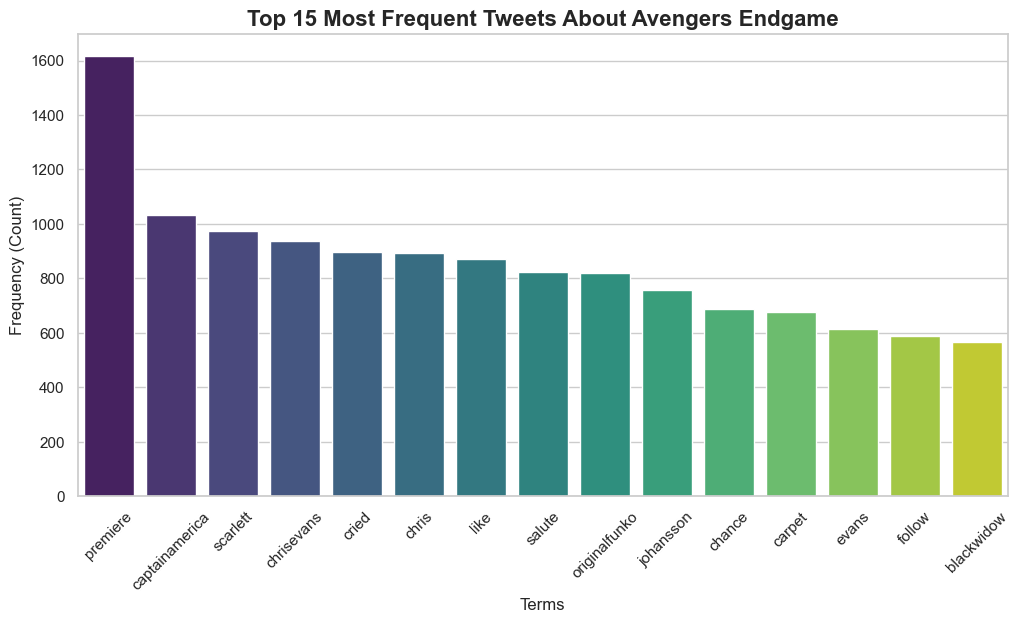

In [35]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(x=words_to_plot, y=counts_to_plot, palette="viridis")

plt.title('Top 15 Most Frequent Tweets About Avengers Endgame', fontsize=16, fontweight='bold')
plt.xlabel('Terms', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.xticks(rotation=45)

plt.show()